<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Calum_ML_playaround.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

___
## Precursor bash commands

In [1]:
# INSTALL ANACONDA (NEEDED FOR RDKIT)
! pip install pynndescent

! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

! conda install -yq -c rdkit rdkit   # need for fingerprints
! conda install -yq -c conda-forge dscribe  # other features
! conda install -y -c conda-forge umap-learn
! conda install -y -c conda-forge tqdm


def download_published_data():
  import io
  from datetime import datetime
  import zipfile

  import requests

  start = datetime.now()
  print(start)
  r = requests.get('https://people.bath.ac.uk/crh53/m1507656.zip')
  zipped = zipfile.ZipFile(io.BytesIO(r.content))
  zipped.extractall('')
  finish = datetime.now()
  print(finish)
  print(finish - start)

download_published_data()
% cd m1507656/

--2021-08-10 09:20:02--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.131.3, 104.16.130.3, 2606:4700::6810:8303, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.131.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’

Miniconda3-py37_4.8 100%[===================>]  81.12M   198MB/s    in 0.4s    

2021-08-10 09:20:03 (198 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: \ | / - \ | / - \ 
The environment is inconsistent, please check the package plan carefully
The following packages are causing the inconsistency:

  - conda-forge/linux-64::umap-learn==0.5.1=py37h89c1867_1
  - conda-forge/noarch::munkres==1.1.4=pyh9f0ad1d_0
  - defaults/linux-64::py-boost==1.73.0=py37ha9443f

___
# Data Mess Around

In [14]:
import io

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
#import umap

from rdkit.Chem import MolFromSmiles
from rdkit.Chem import AllChem, DataStructs
from ase.io import read
from dscribe.descriptors import MBTR

In [5]:
df = pd.read_json('df_5k.json', orient='split')
df.head()

,refcode_csd,canonical_smiles,inchi,number_of_atoms,xyz_pbe_relaxed,energies_occ_pbe,energies_occ_pbe0_vac_tier2,energies_occ_pbe0_water,energies_occ_pbe0_vac_tzvp,energies_occ_pbe0_vac_qzvp,energies_occ_gw_tzvp,energies_occ_gw_qzvp,cbs_occ_gw,energies_unocc_pbe,energies_unocc_pbe0_vac_tier2,energies_unocc_pbe0_water,energies_unocc_pbe0_vac_tzvp,energies_unocc_pbe0_vac_qzvp,energies_unocc_gw_tzvp,energies_unocc_gw_qzvp,cbs_unocc_gw,total_energy_pbe,total_energy_pbe0_vac_tier2,total_energy_pbe0_water,total_energy_pbe0_vac_tzvp,total_energy_pbe0_vac_qzvp,hirshfeld_pbe,hirshfeld_pbe0_vac_tier2,hirshfeld_pbe0_water
10,FOVWES,COC(=O)[C@H](n1c(=S)sc(c1CC)C)C\t\n,InChI=1S/C10H15NO2S2/c1-5-8-7(3)15-10(14)11(8)...,30,30\n\nS 36.75934695 47.20389183 ...,"[-2412.24039, -2409.98986, -512.34265, -510.73...","[-2438.90946, -2436.50894, -524.75994, -523.16...","[-2439.12701, -2436.92988, -525.03583, -523.66...","[-2440.78485, -2438.41749, -524.75752, -523.11...","[-2439.03194, -2436.67645, -524.81876, -523.19...","[-29.1271, -24.9308, -24.2622, -23.3517, -22.6...","[-29.2628, -25.0892, -24.3714, -23.5214, -22.8...","[-29.36351, -25.20675, -24.45244, -23.64734, -...","[-1.79638, -1.16331, -0.8942200000000001, -0.7...","[-1.00989, -0.28629000000000004, -0.0223]","[-1.3107600000000001, -0.37236]","[-0.94898, -0.04764]","[-1.01171, -0.17985]",0.5708,0.2503,0.01245,-37957.125810,-37959.436725,-37959.781206,-37955.151866,-37958.392015,"[0.10253628000000001, 0.00547996, -0.012183910...","[0.09987054000000001, 0.02339617, -0.02340592,...","[0.10696537, 0.01796455, -0.01695311, 0.038783..."
13,FOWGIH,O=P1Oc2ccccc2N(c2c(O1)cccc2)c1ccccc1O\t\n,InChI=1S/C18H14NO4P/c20-16-10-4-1-7-13(16)19-1...,38,38\n\nH 12.71064531 19.89742093 ...,"[-2091.34232, -512.89603, -512.82777, -511.071...","[-2116.2313, -525.35737, -525.2753, -523.39362...","[-2116.36062, -525.43865, -525.32768, -524.020...","[-2117.92912, -525.37336, -525.29157, -523.373...","[-2116.40386, -525.41418, -525.33251, -523.431...","[-29.1772, -28.1356, -25.4081, -25.0932, -24.3...","[-29.3487, -28.3072, -25.5324, -25.2152, -24.5...","[-29.49661, -28.4552, -25.63961, -25.32042, -2...","[-1.95194, -1.7190400000000001, -1.4932, -1.40...","[-1.0777700000000001, -0.8311200000000001, -0....","[-1.02904, -0.81579, -0.7339100000000001, -0.5...","[-1.0339, -0.7883600000000001, -0.568000000000...","[-1.07954, -0.8363700000000001, -0.61953, -0.5...",0.4221,0.1608,-0.06456,-37897.107973,-37898.626863,-37898.981311,-37894.899503,-37897.489935,"[0.05218846, 0.05394222, -0.03803773, -0.04503...","[0.05369862, 0.05568369, -0.03772409, -0.04654...","[0.06260278, 0.06495193, -0.037864499999999995..."
16,FOWZUN01,COc1cc(/C=N/NC(=O)C)ccc1OC\t\n,InChI=1S/C11H14N2O3/c1-8(14)13-12-7-9-4-5-10(1...,30,30\n\nO 52.68107801 40.00990379 ...,"[-512.23333, -512.0378, -510.09269, -382.82501...","[-524.54893, -524.35885, -522.49983, -393.7126...","[-524.74742, -524.66529, -523.1113, -393.88073...","[-524.53793, -524.34385, -522.42474, -393.6580...","[-524.60145, -524.40947, -522.51429, -393.7501...","[-29.3566, -25.1244, -24.6401, -23.5505, -22.0...","[-29.457, -25.3739, -24.8026, -23.0988, -22.44...","[-29.53444, -25.56633, -24.92793, -22.75042, -...","[-2.18158, -0.9446100000000001, -0.55918, -0.3...","[-1.38562, -0.050980000000000004]","[-1.62935, -0.25269]",[-1.3227600000000002],"[-1.37606, -0.0553]",[0.1763],[-0.0988],[-0.31098000000000003],-20757.356135,-20757.760932,-20758.252762,-20756.008159,-20757.333450,"[-0.0919376, -0.09781358, 0.05549081, -0.06736...","[-0.11444561, -0.11968959, 0.06339492000000001...","[-0.13184671, -0.13691553, 0.0551235, -0.07349..."
24,FOYJUZ,CC(=O)c1c(O)cc2c(c1C(F)(F)F)CCCCC2\t\n,InChI=1S/C14H15F3O2/c1-8(18)12-11(19)7-9-5-3-2...,34,34\n\nC 31.38645310 35.92076832 ...,"[-662.24711, -662.10763, -662.09557, -512.4229...","[-676.21662, -676.06812, -676.06049, -524.8213...","[-676.56678, -676.3723, -676.322, -524.71868, ...","[-676.33183, -676.17593, -676.16415, -524.7950...","[-676.38177, -676.2319

In [6]:
df['rdkit'] = df['canonical_smiles'].apply(MolFromSmiles)
df = df[~df['rdkit'].isna()]  # exclude invalid smiles codes

In [7]:
def mol_to_ecfp(mol, r=6, b=1024):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, r, nBits=b)
    array = np.zeros((0,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, array)
    return array

df['fingerprint'] = df['rdkit'].apply(mol_to_ecfp)

In [8]:
df['fingerprint'].isna().sum()

0

In [9]:
X = np.vstack(df['fingerprint'].values)

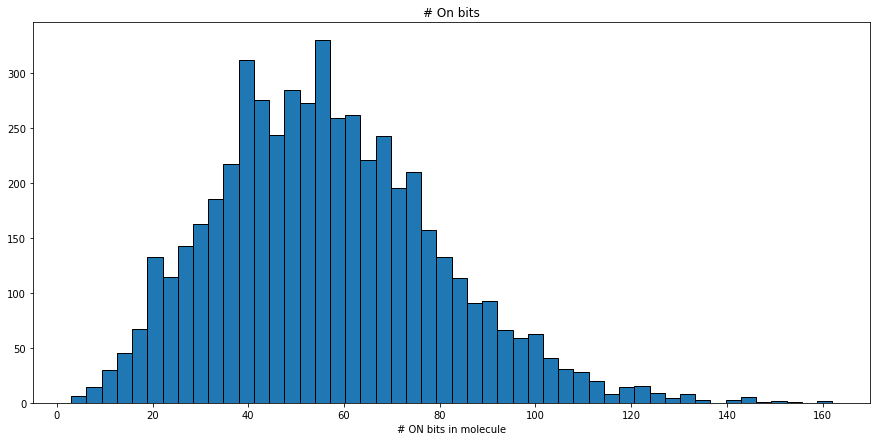

In [10]:
plt.figure(figsize=(15, 7))
plt.hist(X.sum(1), edgecolor="black", bins=50)
plt.title('# On bits')
plt.xlabel('# ON bits in molecule')
plt.show()

In [11]:
a = df['fingerprint'].drop_duplicates()
print(len(df) - len(a), 'Dulplicate fingerprints')

0 Dulplicate fingerprints


* Minority of bits are set and no duplicate fingerprints exist

In [12]:
similarities = 1 - pairwise_distances(X, X, metric='jaccard', n_jobs=-1)

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/pairwise.py:1738: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


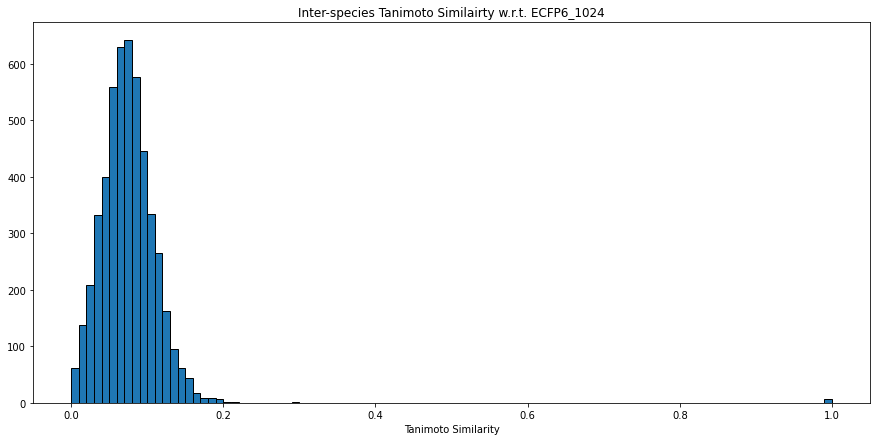

In [13]:
sample = np.random.choice(similarities.ravel(), 5000, replace=False)

plt.figure(figsize=(15, 7))
plt.hist(sample, bins=100, edgecolor="black")
plt.title('Inter-species Tanimoto Similairty w.r.t. ECFP6_1024')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('')
plt.show()

* From low similarity distribution it seems that molecules are diverse w.r.t. themselves

### Visualisation of fingerprints and target values using `t-SNE` 
* Ideally would use `UMAP` but issues installing on collab
* Will try `t-SNE` since this allows for `jaccard` distance metric to be used

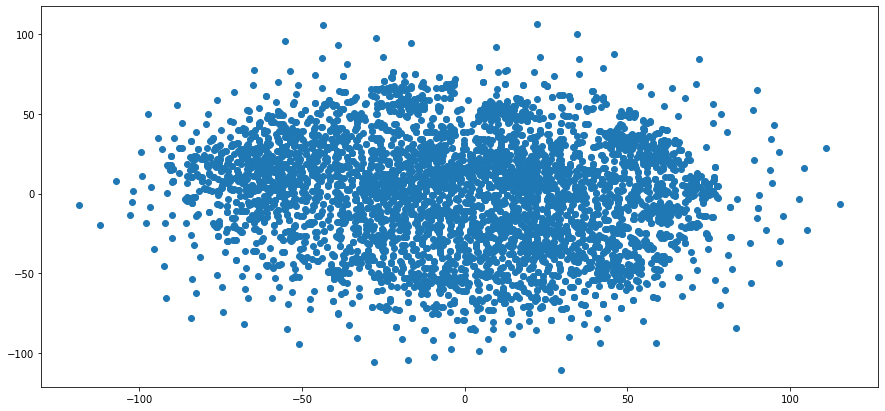

In [16]:
reducer = TSNE(metric='jaccard', n_components=2)  # 2 output columns
embedding = reducer.fit_transform(X)

plt.figure(figsize=(15, 7))
plt.scatter(embedding[:, 0], embedding[:, 1])
plt.show()

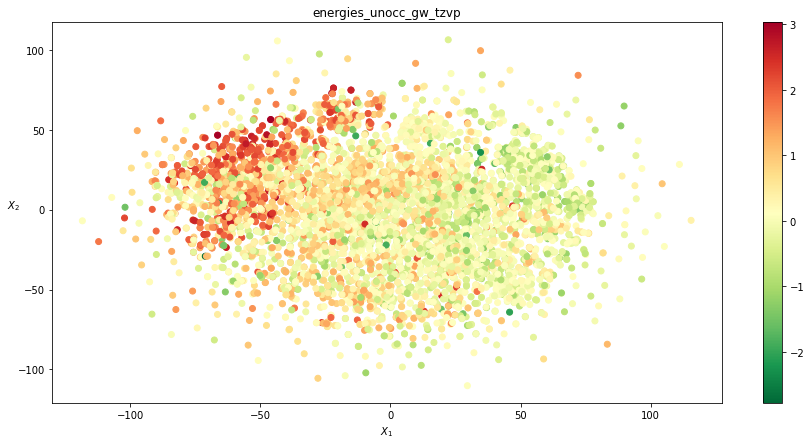

In [20]:
col = 'energies_unocc_gw_tzvp'

y = df[col].apply(lambda x: x if isinstance(x, float) else x[-1])

plt.figure(figsize=(15, 7))
plt.title(col)
p = plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='RdYlGn_r')
plt.colorbar(p)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$', rotation=0)
plt.show()

* Curious how well it performs w.r.t "*proper*" target values

* some partial structure in the data w.r.t. the energies of `LUMO` (?) in this case seen by fuzzy colour transition 

___
## Generation of `MBTR`

In [30]:
def xyz_to_atoms(xyz):
    file = io.StringIO()
    file.write(xyz)
    return read(file, format='xyz')

In [31]:
df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_to_atoms)
df['unique_atomic_numbers'] = df['atoms'].apply(lambda x: list(set(x.numbers)))
all_atomic_numbers = set([a for b in df['unique_atomic_numbers'] for a in b])

NameError: ignored

In [ ]:
mbtr = feature_calc  = MBTR(
    species=all_atomic_numbers,
    k2={
        "geometry": {"function": "inverse_distance"},
        "grid": { "min": 0, "max": 0.7, "sigma": 0.01, "n": 200 },
        "weighting": {"function": "exp", "scale": 0.75, "cutoff": 1e-3}
    },
    k3={
        "geometry": {"function": "cosine"},
        "grid": { "min": -1.0, "max": 1.0, "sigma": 0.05, "n": 200 },
        "weighting": {"function": "exp", "scale": 0.5, "cutoff": 1e-3}
    },
    periodic=False,
    normalization="l2_each",
    flatten=True
)